# DIC1 Example

In this notebook, we are looking specifically at the DIC1 gene.

From our PTR analysis, it seemed like this gene had a large region of high peak to trough ratio chromatin.

In this notebook, we are examining what specifically about this gene's chromatin appears to be cycling. Whether it is an artifact of normalization. As well as developing some plotting and visualization techniques that can best convey interesting results (true or artifactual)

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [512]:
from cc_src.chromatin_grid_compute import ChromatinGrid

chromatin_gridder = ChromatinGrid()

gene_name = 'DIC1'
chromatin_gridder.set_gene(gene_name)

chromatin_gridder.create_bins_per_all_sample()
chromatin_gridder.create_deconvolution_matrices()

from src.config import load_yl_replicate2_rg1_chromatin_config, \
    load_xg_gene_expression_config
from src.model import Model

config = load_yl_replicate2_rg1_chromatin_config()
chrom_model = Model(config, gene_name, 0.004)
print("The shape of the convolution kernel matrix, H is: ", chrom_model.H.shape)


Loading MNase reads...Done.
The histogram shape around the TSS is: (3, 9)
Now we have a data structure that we can try to deconvolve of shape: (15, 27)
The shape of the convolution kernel matrix, H is:  (15, 226)


In [513]:
from src.deconvolve_chromatin import plot_deconvolved_chromatin
from src.deconvolve_chromatin import deconvolve_chromatin
from src.timer import Timer

timer = Timer()
result, f = deconvolve_chromatin(chrom_model, chromatin_gridder.deconv_hist)
print(f"Completed in {timer.get_time()}")
print(f"  The result was {result:.2f} and an F matrix of size {f.shape}")

Completed in 00:00:25.50
  The result was 8.71 and an F matrix of size (226, 27)


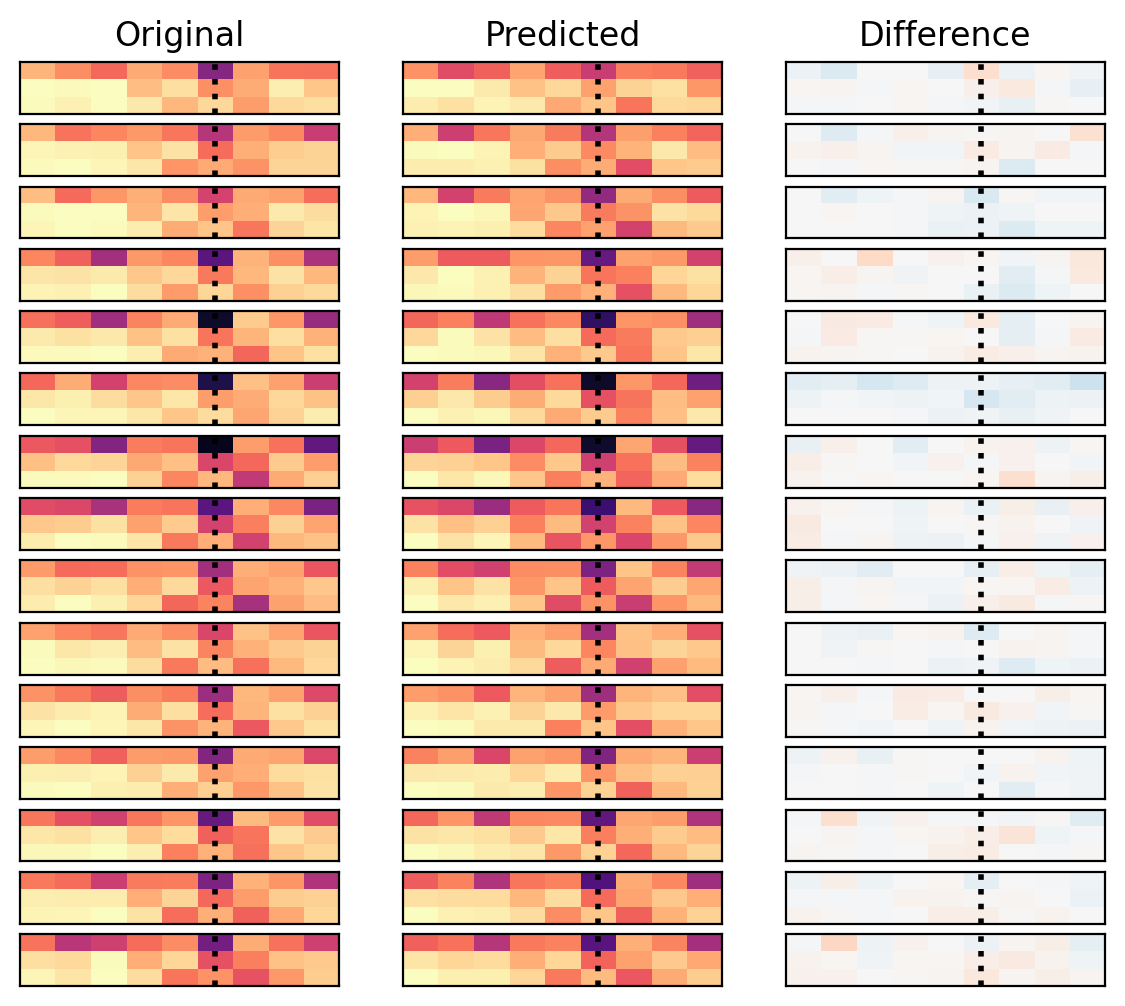

In [514]:
chromatin_gridder.plot_prediction_comparison(chrom_model, f)

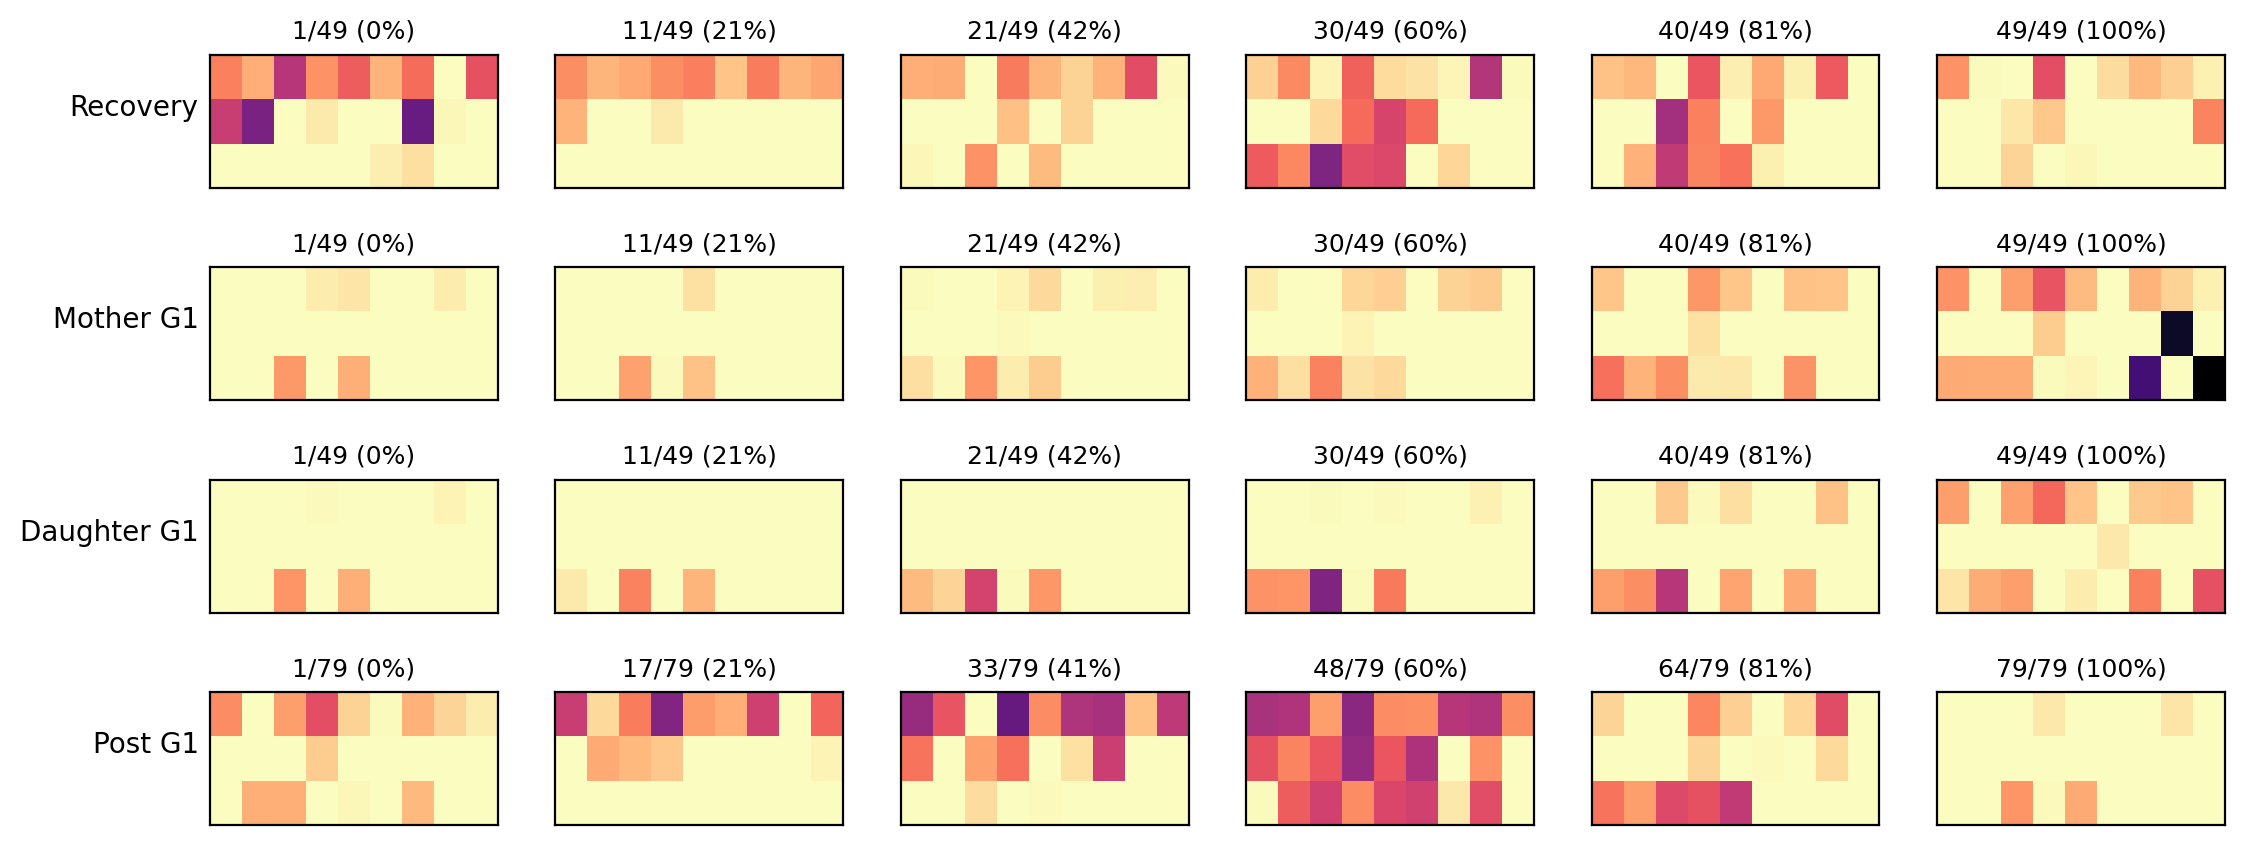

In [515]:
fig, ax_rows = plt.subplots(4, 6, figsize=(13, 5))
plt.subplots_adjust(hspace=0.6)
        
# Abbreviated plot which allows us to better understand what is going on in each sub-phase
chromatin_gridder.create_deconvolution_plots_abbreviated(f, chrom_model, ax_rows)

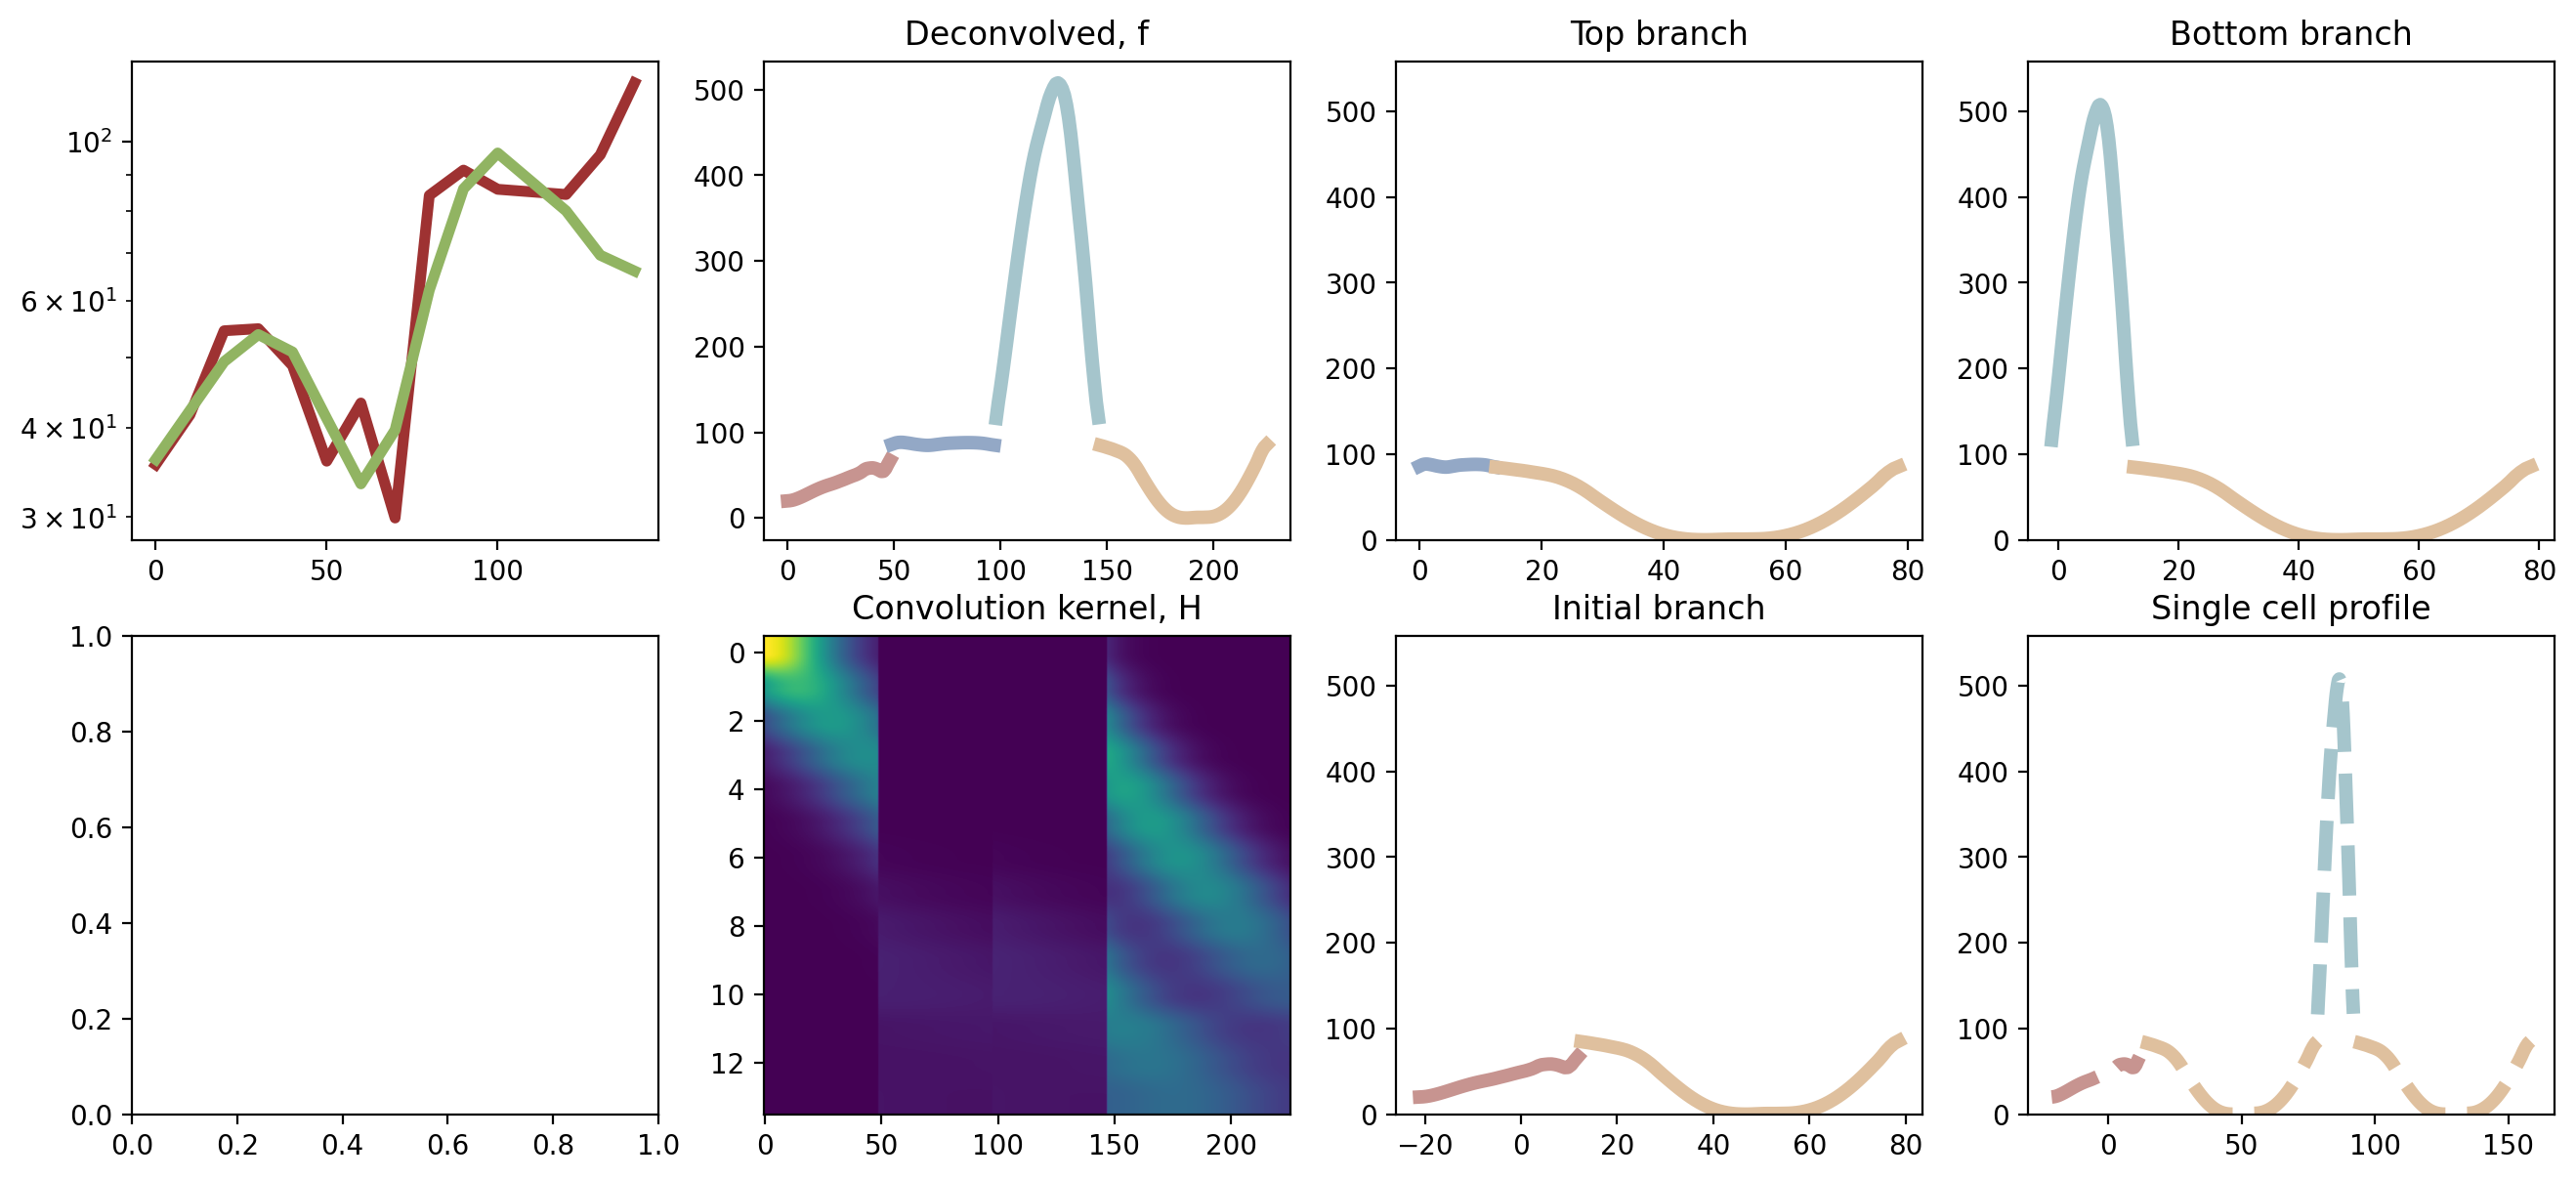

In [408]:
ge_model.plot_deconvolved_gene()

In [517]:
from src.deconvolution_plotter import DeconvolutionPlotter

deconv_plotter = DeconvolutionPlotter(ge_model, chromatin_gridder, chrom_model)

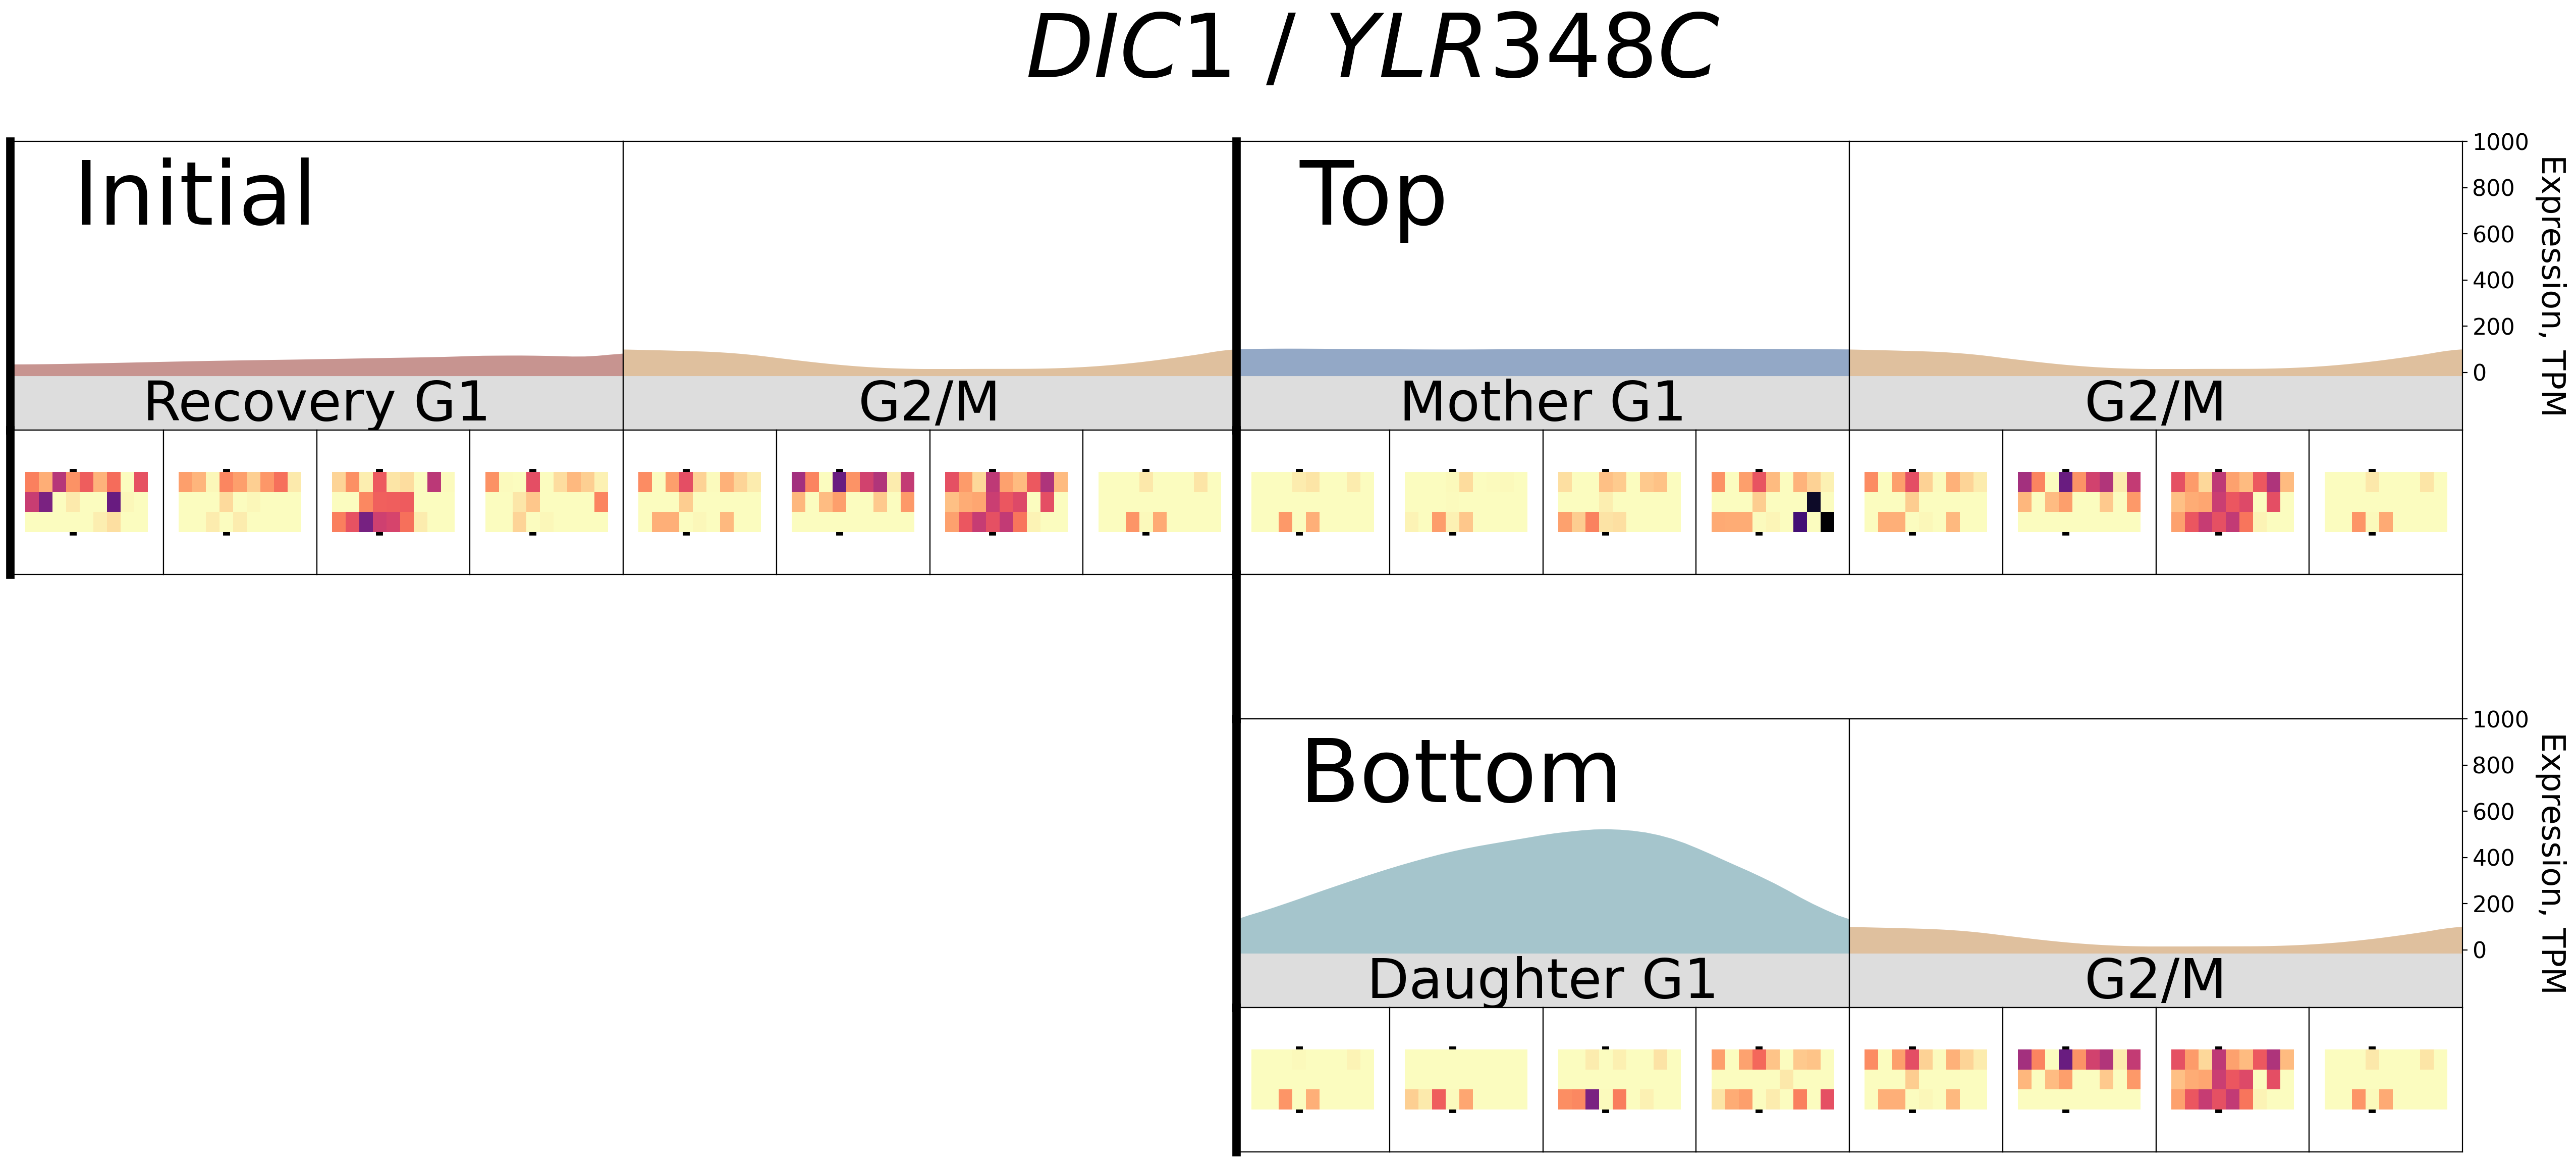

In [518]:
deconv_plotter.plot_deconvolved_models()

In [451]:
# Next we will do the same, without needing to deconvolve
# we want to be able to load the deconvolution results from disk and plot

In [549]:
chromatin_directory_path = 'output/deconvolve_chromatin_2023_12_15/'
gene_expression_directory_path = 'output/deconvolve_gene_expression_2024_01_04/'

output/deconvolve_chromatin_2023_12_15/837_meta_YLR348C.csv
output/deconvolve_gene_expression_2024_01_04/3837_meta_YLR348C.csv
Loading MNase reads...Done.
Now we have a data structure that we can try to deconvolve of shape: (15, 27)


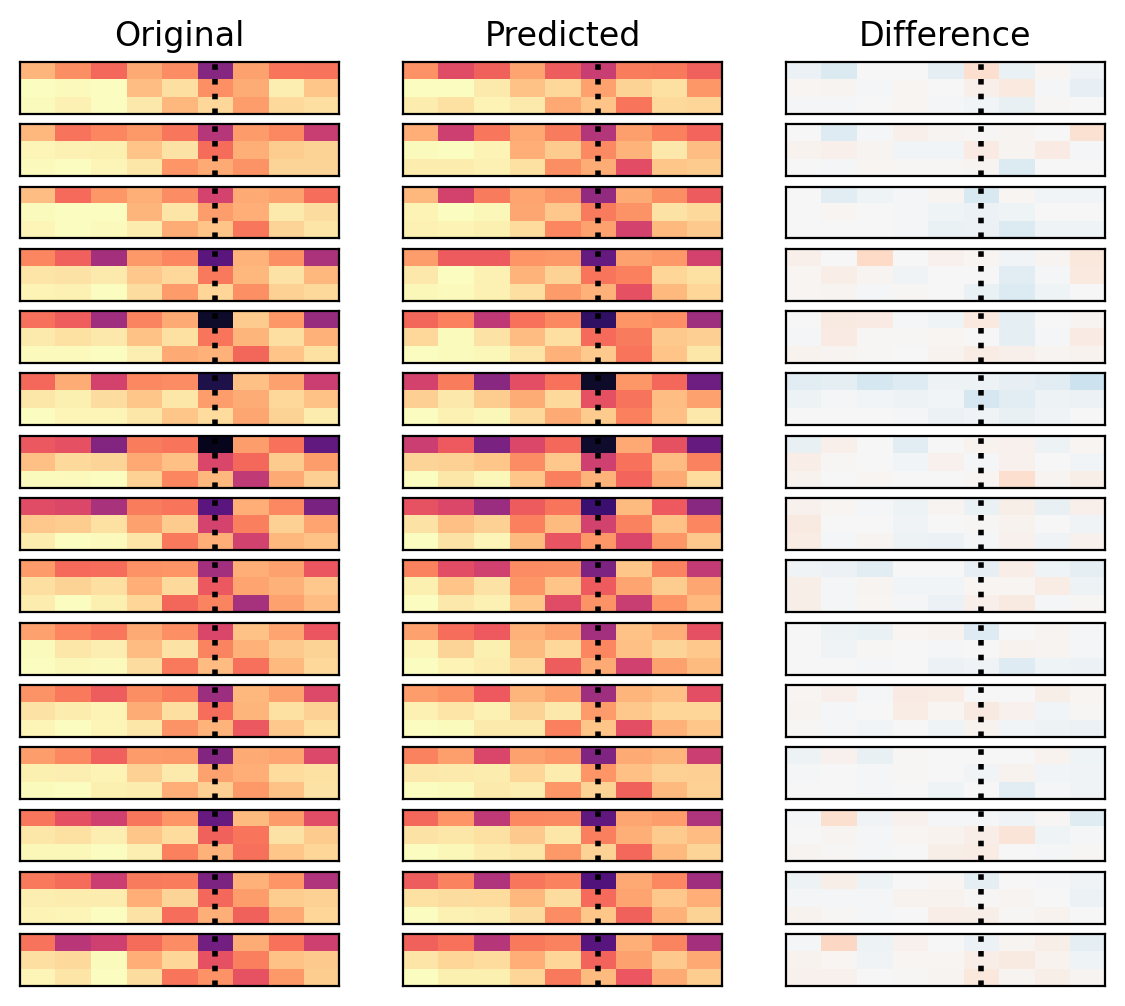

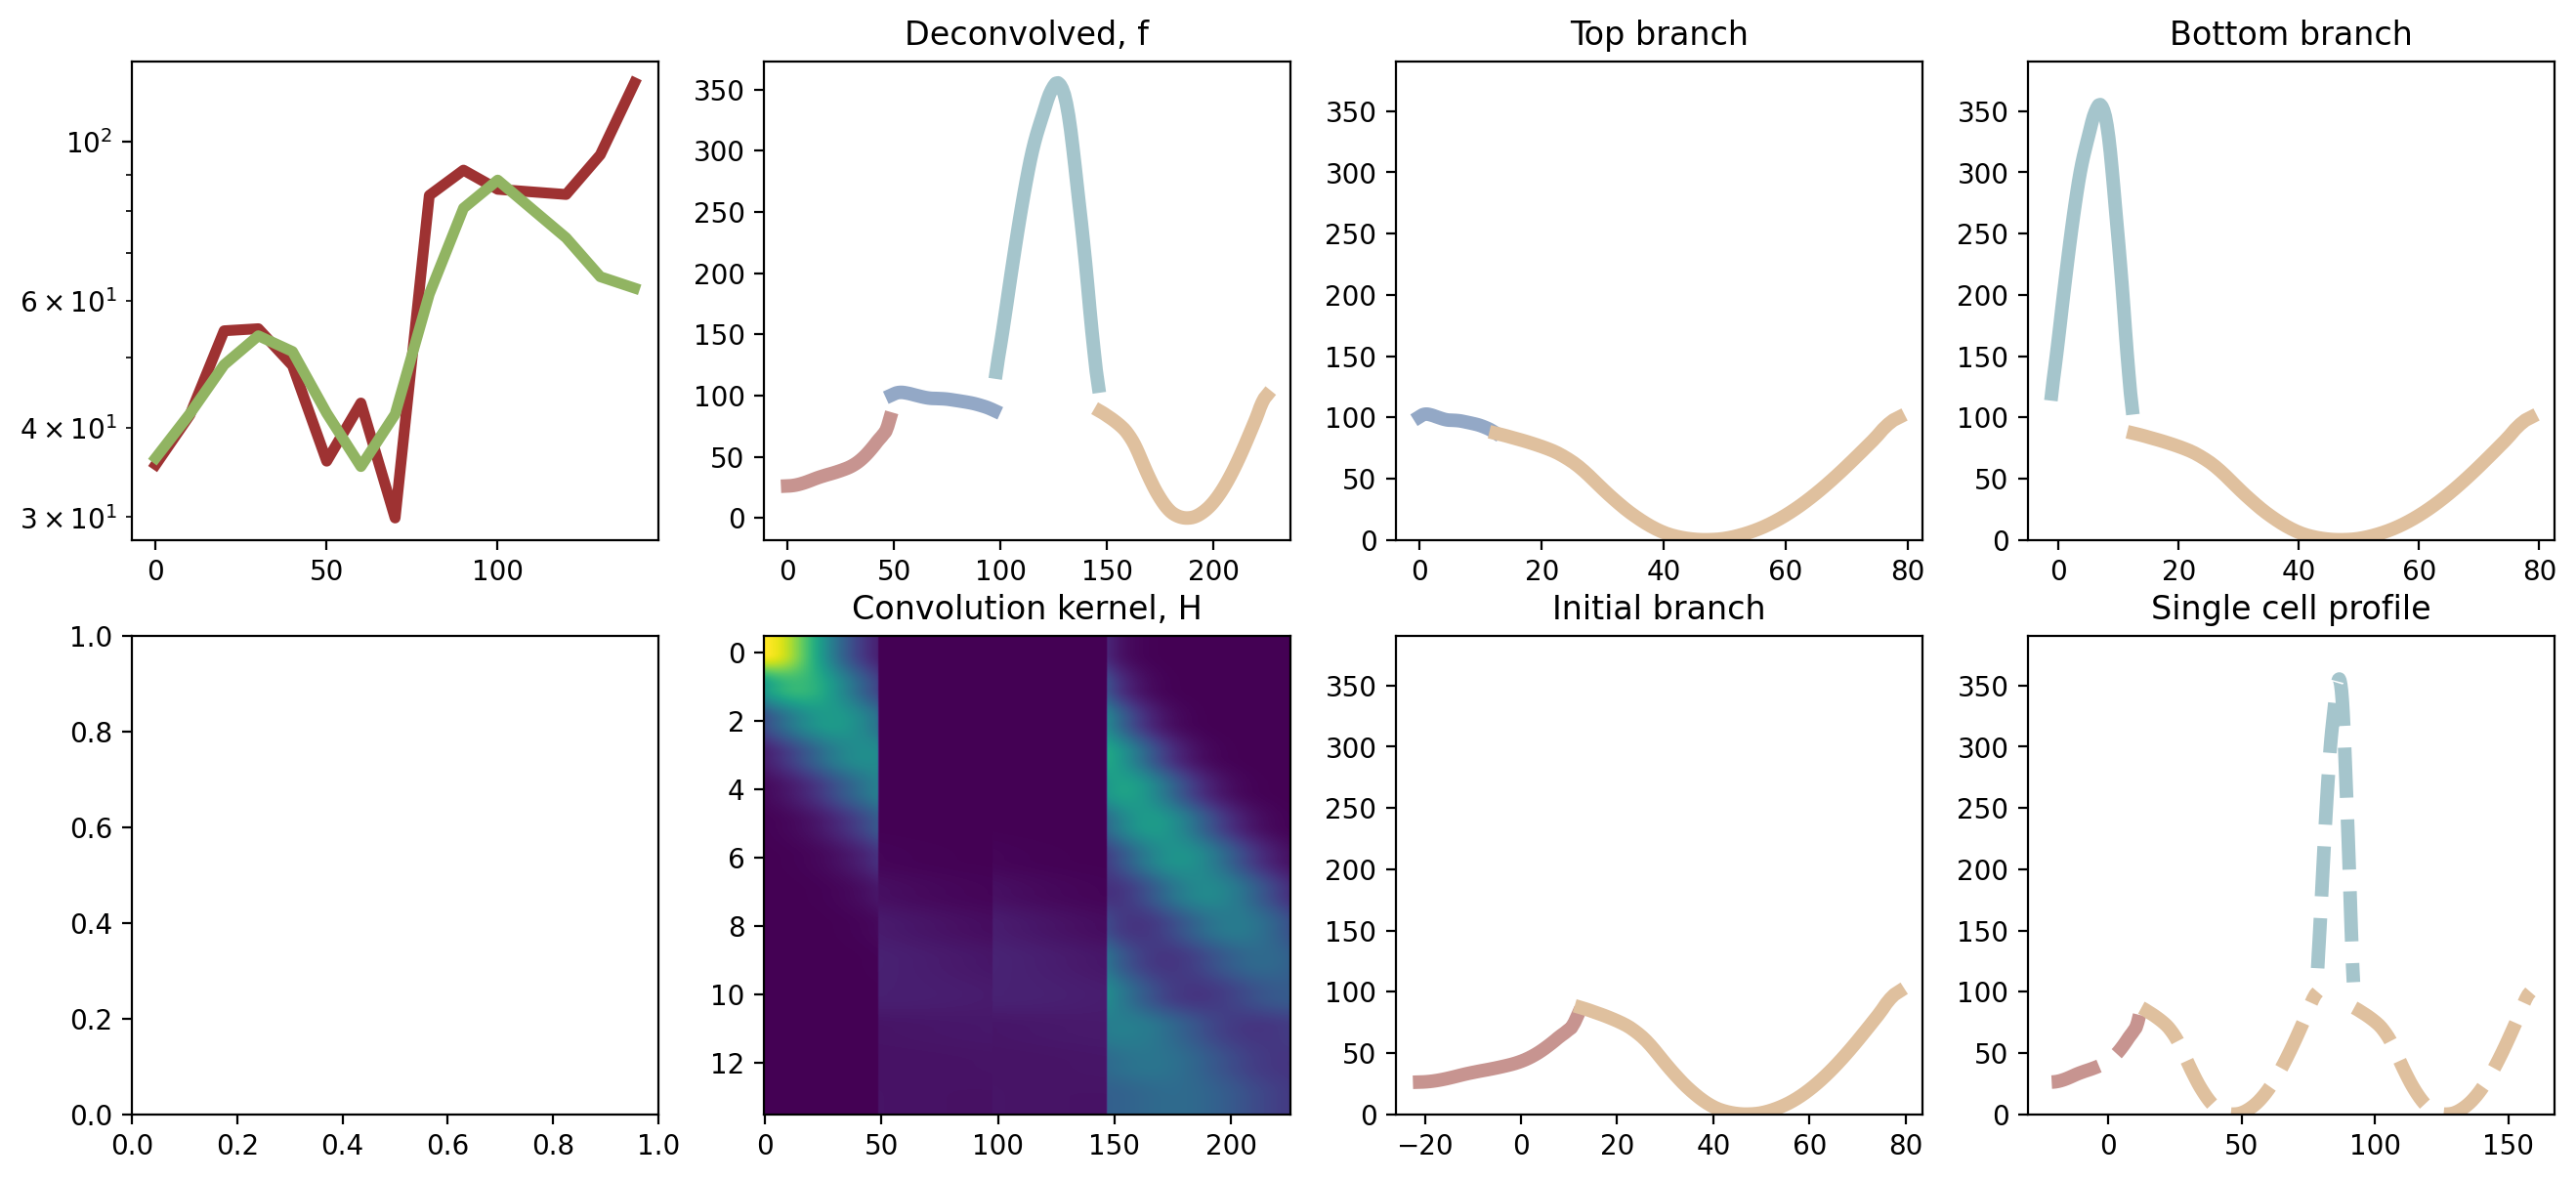

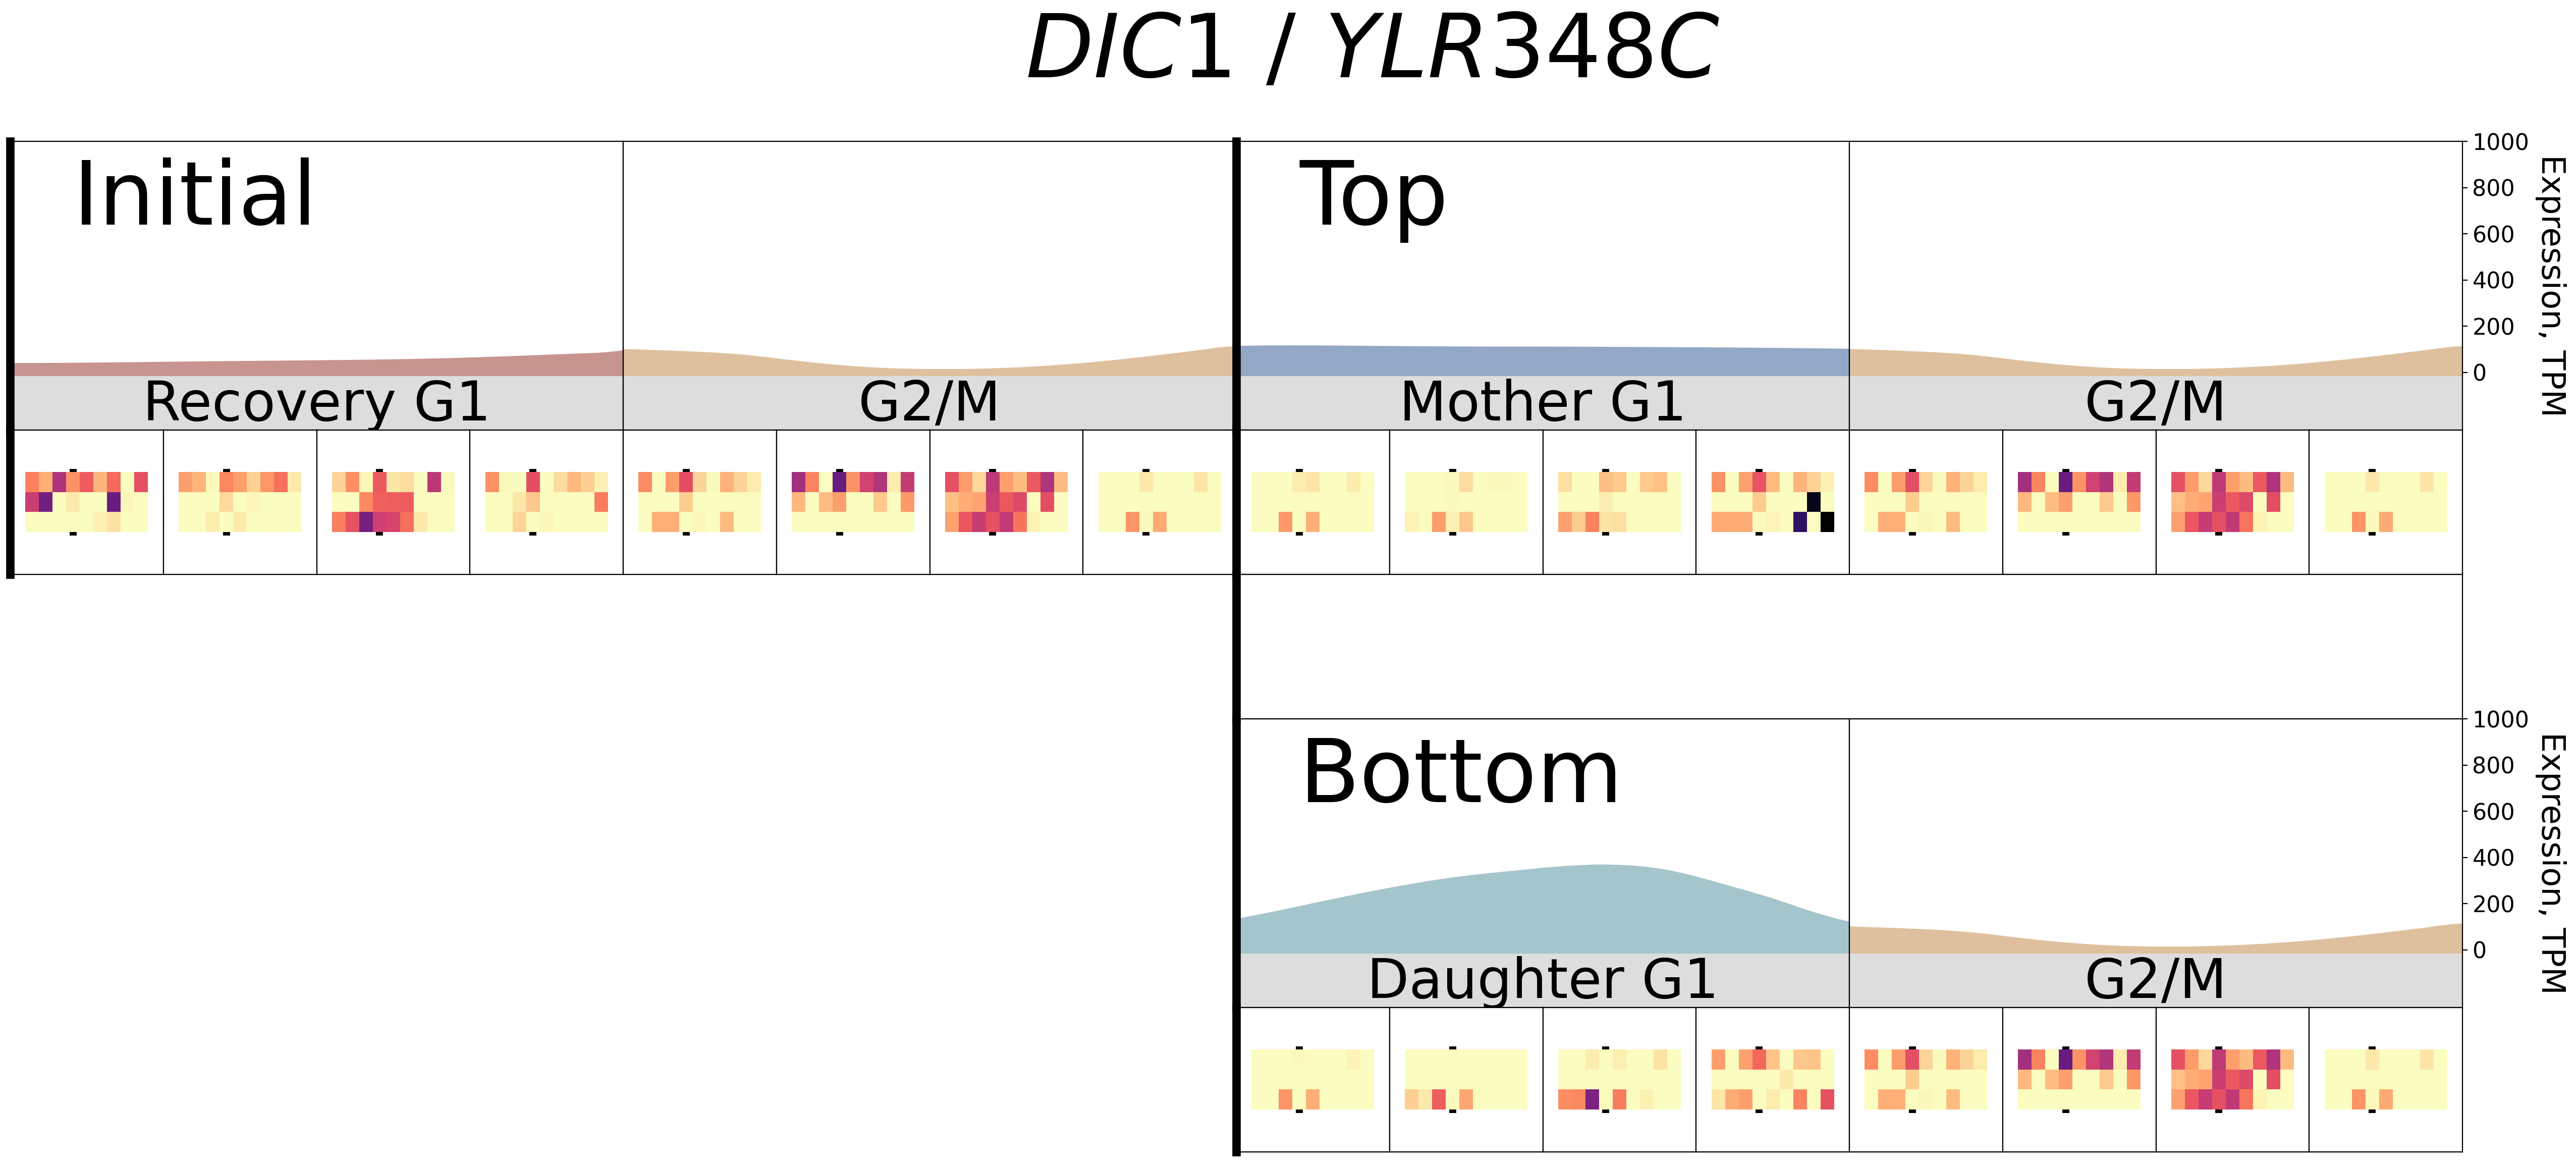

In [550]:
from src.deconvolution_plotter import load_deconvolution_models_from_disk

gene_name = 'DIC1'

deconv_plotter = load_deconvolution_models_from_disk(gene_name, chromatin_directory_path, 
                                    gene_expression_directory_path)

deconv_plotter.chromatin_gridder.plot_prediction_comparison(chrom_model)
deconv_plotter.ge_model.plot_deconvolved_gene()
deconv_plotter.plot_deconvolved_models()

In [585]:
from src.deconvolution_plotter import load_deconvolution_models_from_disk

gene_name = 'CLB2'

deconv_plotter = load_deconvolution_models_from_disk(gene_name, chromatin_directory_path, 
                                    gene_expression_directory_path)


Loading MNase reads...Done.
Now we have a data structure that we can try to deconvolve of shape: (15, 27)


The histogram shape around the TSS is: (3, 9)


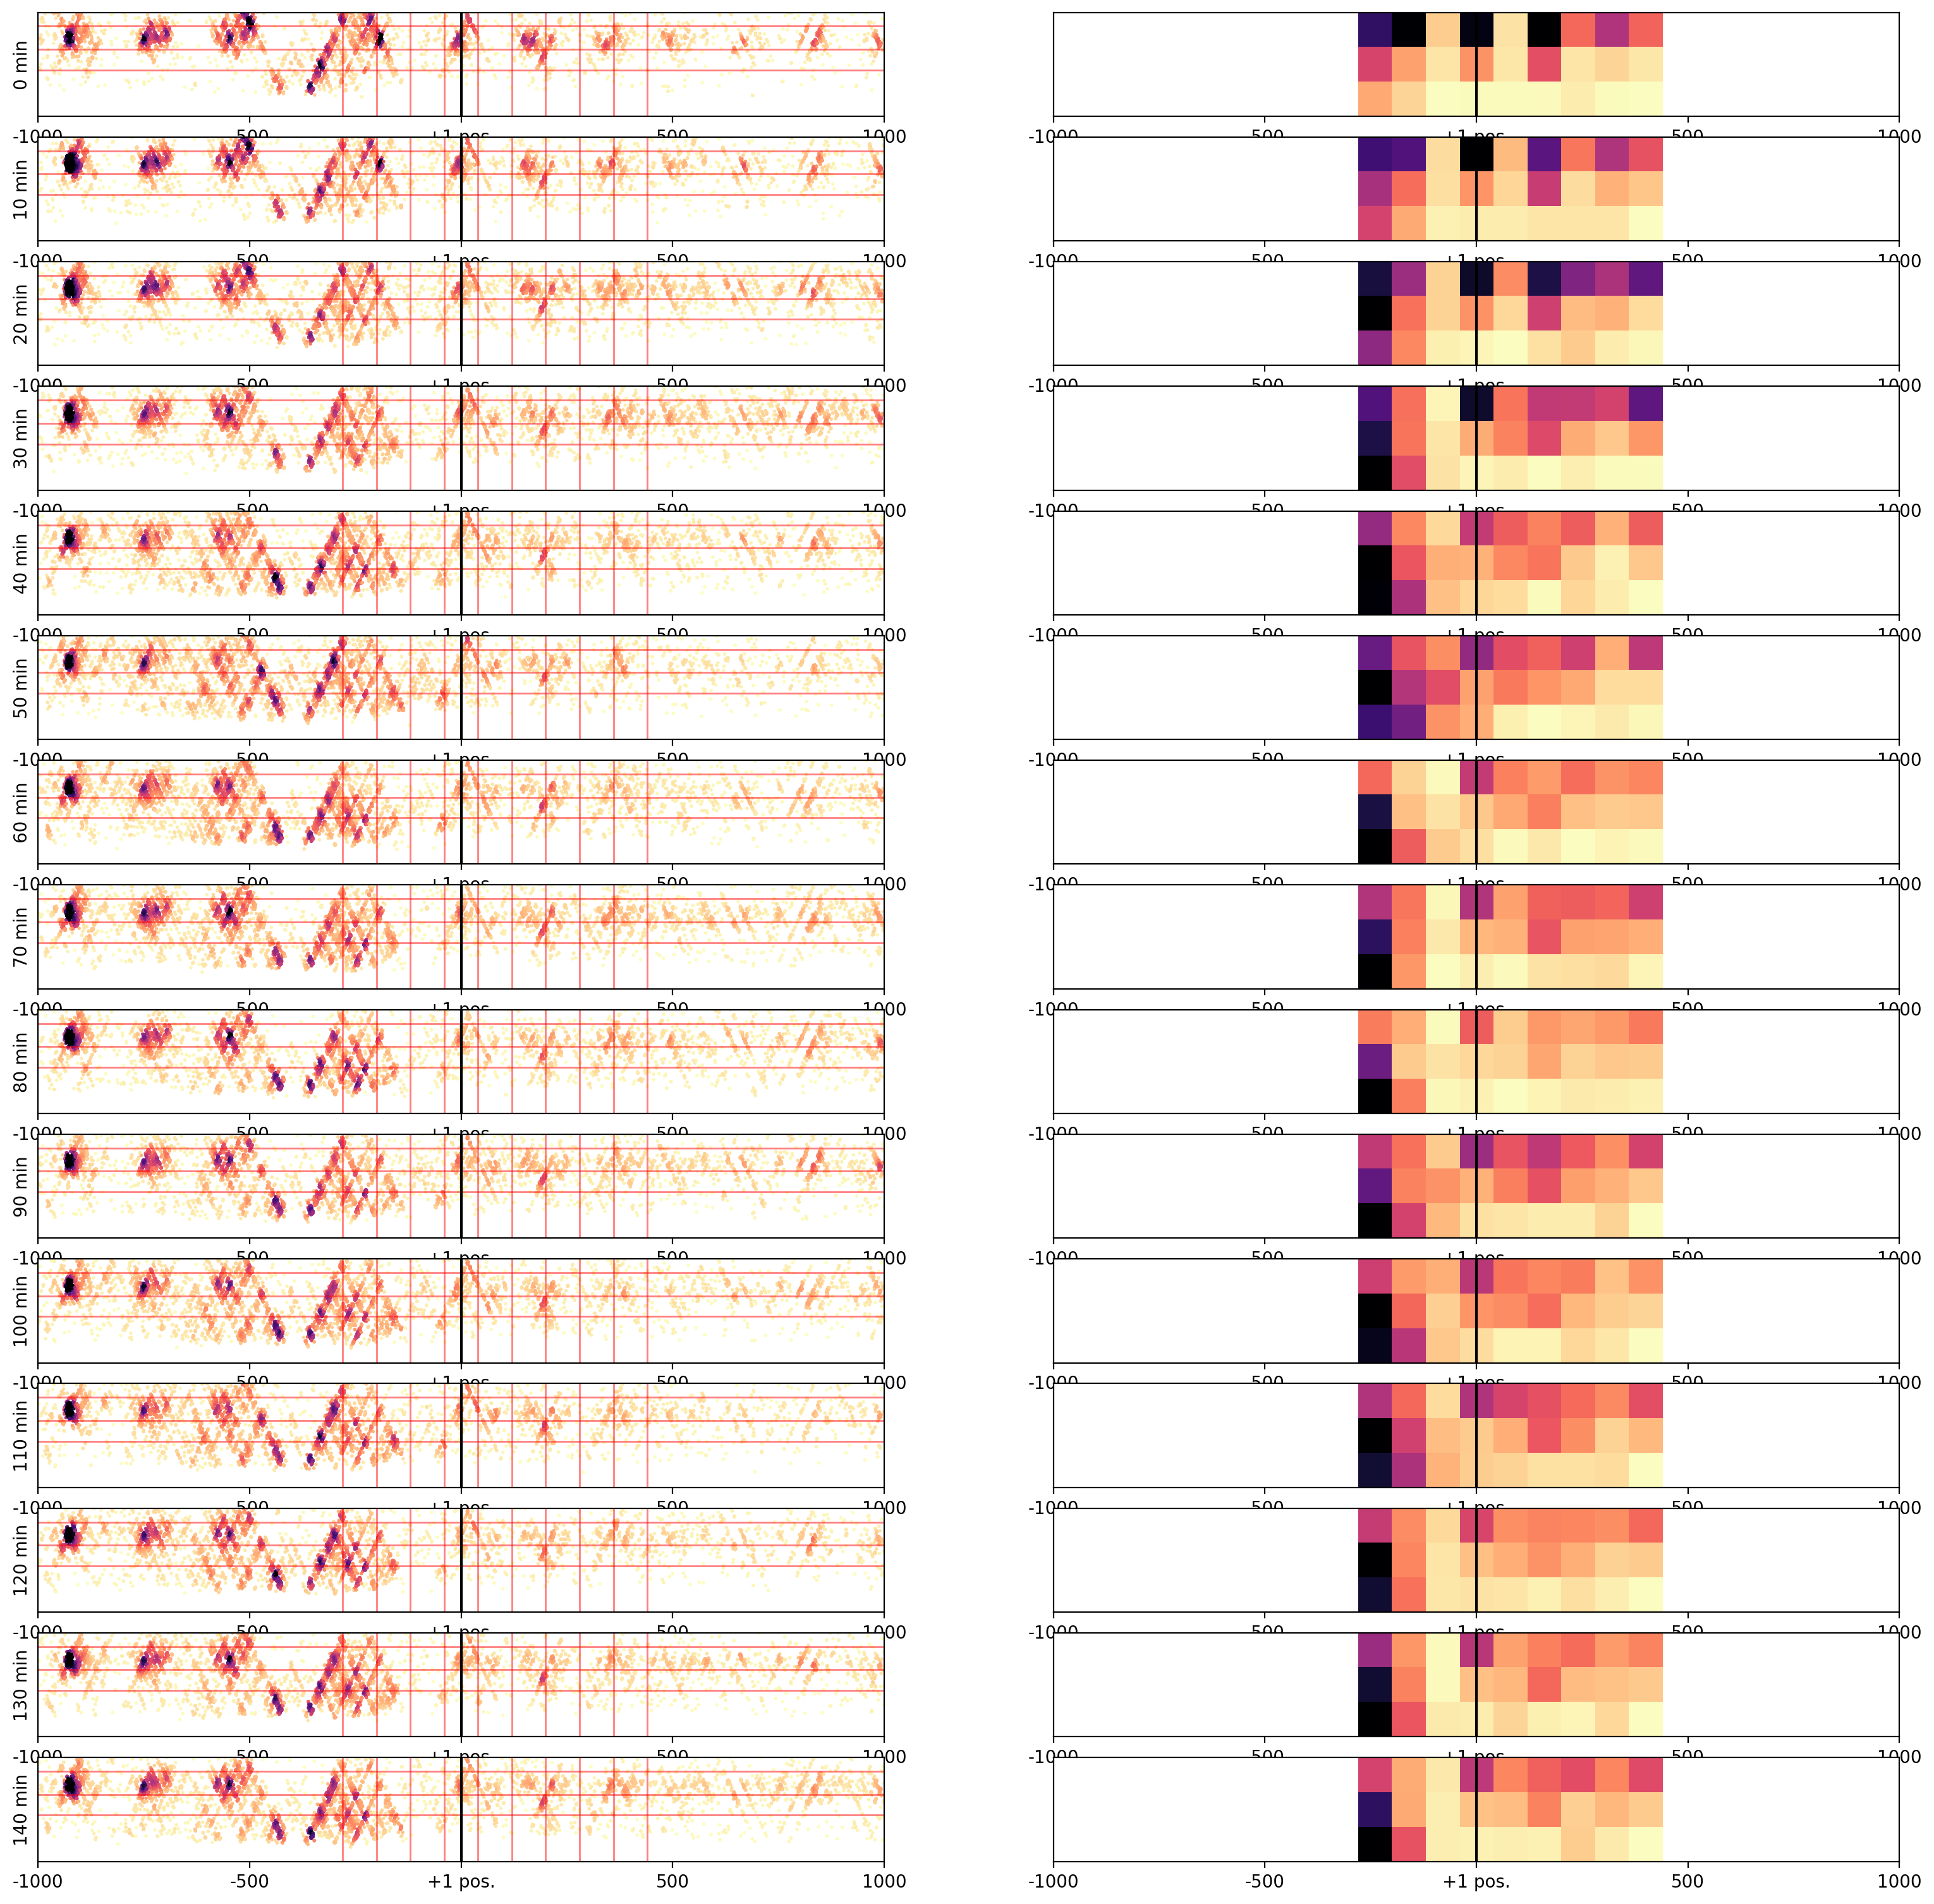

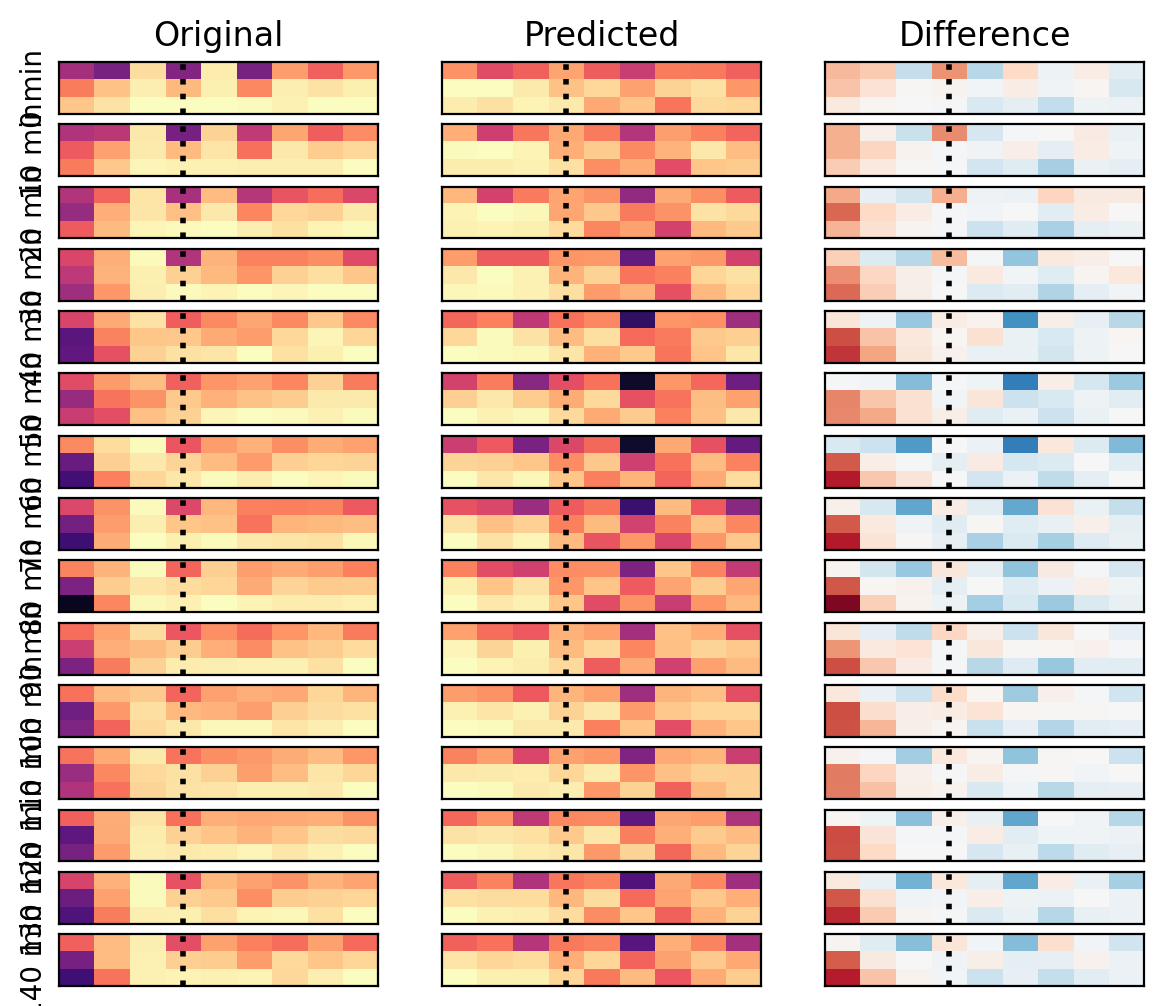

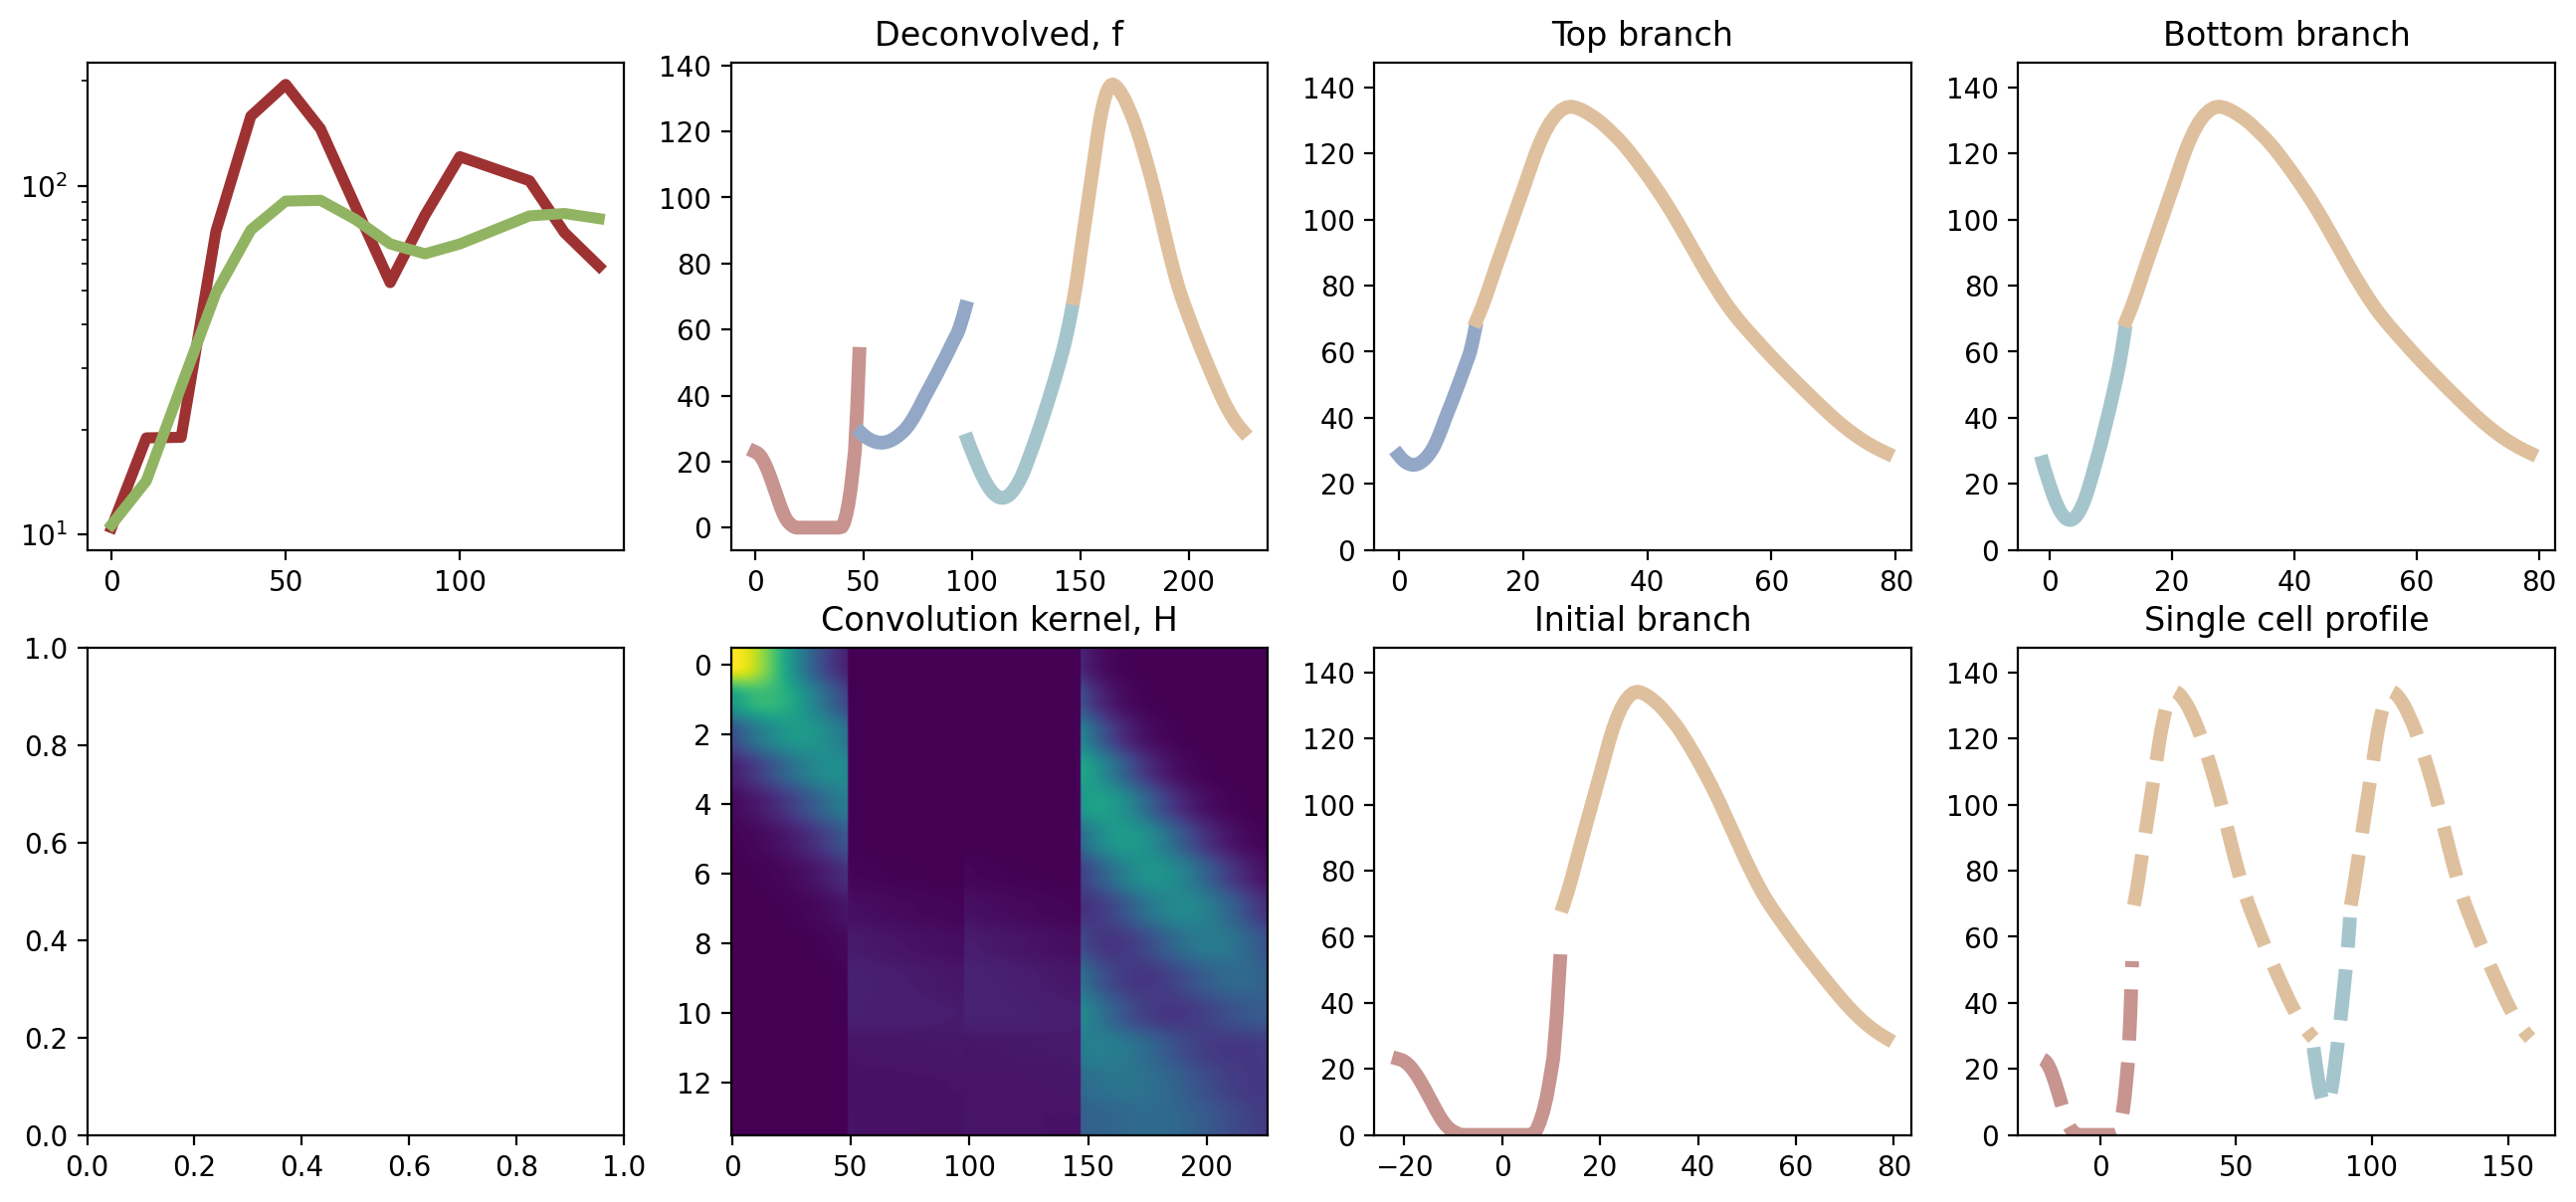

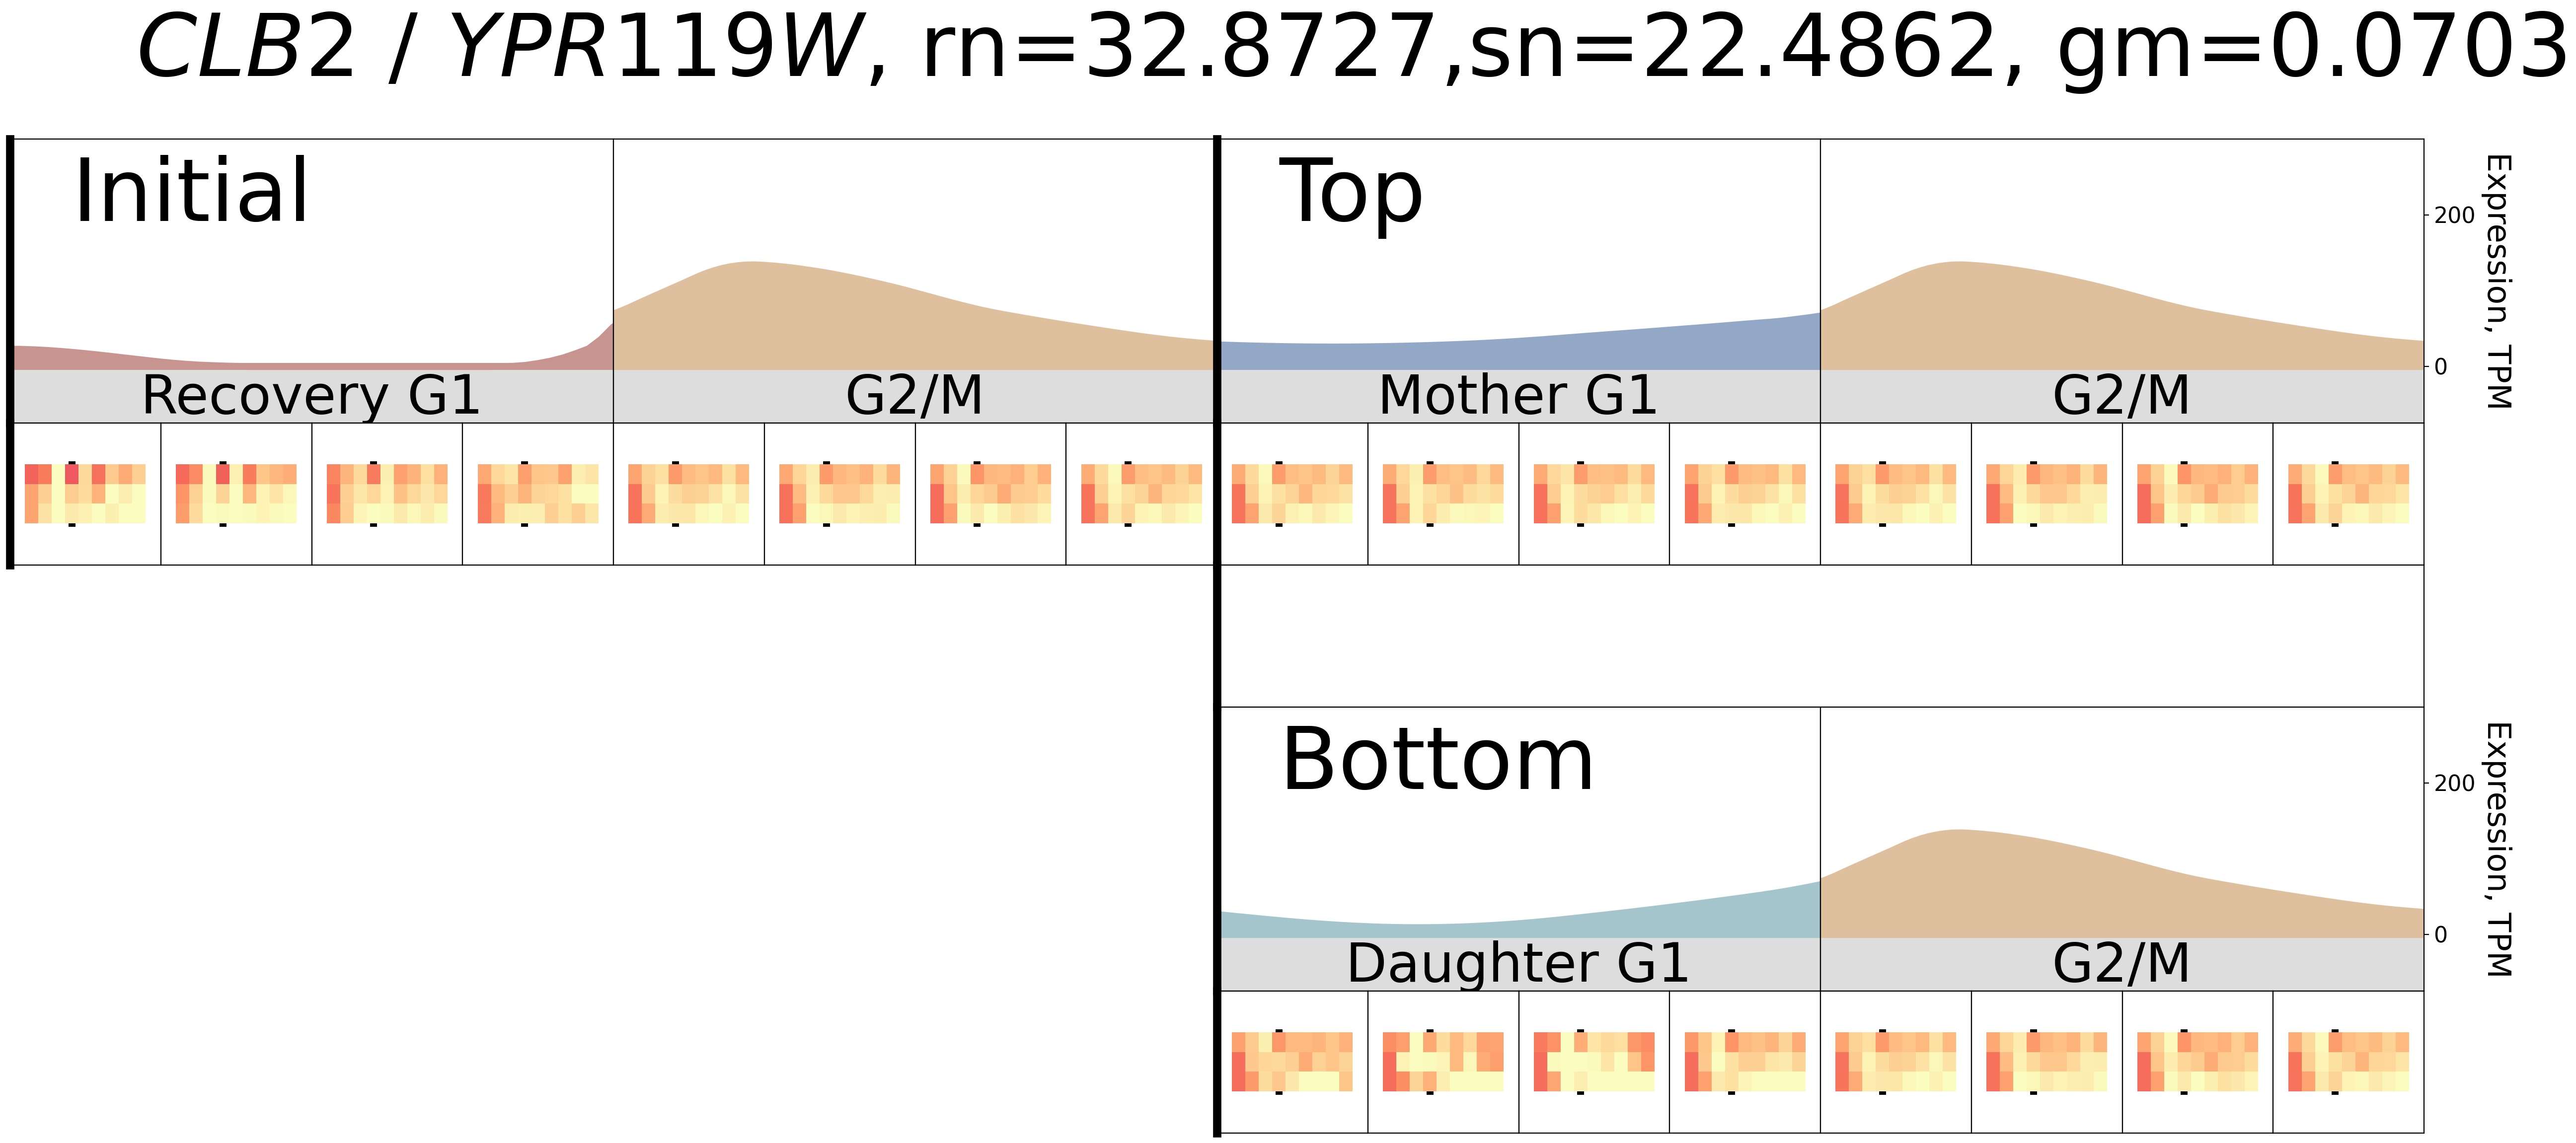

In [587]:
deconv_plotter.chromatin_gridder.create_bins_per_all_sample()
deconv_plotter.chromatin_gridder.plot_raw_and_grid()
deconv_plotter.chromatin_gridder.plot_prediction_comparison(chrom_model)
deconv_plotter.ge_model.plot_deconvolved_gene()
deconv_plotter.plot_deconvolved_models()

In [ ]:
# Create PTR plot and add the rn, sn, and ptr values to the appropriate plots

# Prepare script to create plots for all genes.

# Then, switch to PTR analysis